In [1]:
import pandas, csv, mygene, seaborn, numpy
import scipy, scipy.stats

In [2]:
import matplotlib.pyplot
matplotlib.pyplot.rcParams.update({

    # Figure
    "figure.figsize": (7, 7),
    "figure.dpi": 300,

    # Fonts
    "font.size": 16,
    "axes.titlesize": 20,
    "axes.labelsize": 18,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,

    # Axes appearance
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 1.5,

    # Boxplot defaults
    "boxplot.patchartist": True,
    "boxplot.showfliers": False,

    # Lines
    "lines.linewidth": 2,

    # Savefig
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.05,
})




In [3]:
# 1. table of expression for all conditions

results_folder = '/Users/adrian/research/bmcbf/025_isafjordur/results/000_quantification/'
#results_folder = '/Users/adrian/Library/CloudStorage/ProtonDrive-adrian.rvk@proton.me-folder/scratch/'
expression_file_skmel = results_folder + 'DESeq2_TPM_values.skmel.tsv'
expression_file_u2o2 = results_folder + 'DESeq2_TPM_values.u2.tsv'

expression_skmel = pandas.read_csv(expression_file_skmel, sep='\t', index_col=0)
expression_u2os = pandas.read_csv(expression_file_u2o2, sep='\t', index_col=0)

print(expression_skmel.shape, expression_u2os.shape)

full_expression = pandas.concat([expression_skmel, expression_u2os], axis=1)
print(full_expression.shape)

selected_columns = ['SkMel28-MITFKO_ev_skmel28_rep1', 'SkMel28-MITFKO_ev_skmel28_rep2','SkMel28-MITFKO_ev_skmel28_rep3', 'SkMel28-MITFKO_ev_skmel28_rep4',
       'SkMel28-MITFKO_mitf_x6_rep1', 'SkMel28-MITFKO_mitf_x6_rep3','SkMel28-MITFKO_mitf_x6_rep4', 
        'U2-1_Sc_UT', 'U2-2_Sc_UT', 'U2-3_Sc_UT',
        'U2-1_siMi_UT', 'U2-2_siMi_UT', 'U2-3_siMi_UT']

expression = full_expression.loc[:, selected_columns]
expression

(39546, 7) (39546, 18)
(39546, 25)


,SkMel28-MITFKO_ev_skmel28_rep1,SkMel28-MITFKO_ev_skmel28_rep2,SkMel28-MITFKO_ev_skmel28_rep3,SkMel28-MITFKO_ev_skmel28_rep4,SkMel28-MITFKO_mitf_x6_rep1,SkMel28-MITFKO_mitf_x6_rep3,SkMel28-MITFKO_mitf_x6_rep4,U2-1_Sc_UT,U2-2_Sc_UT,U2-3_Sc_UT,U2-1_siMi_UT,U2-2_siMi_UT,U2-3_siMi_UT
ENSG00000000003,9.097209,9.806654,12.244351,12.179835,17.984601,12.499056,10.895395,30.818057,5.939035,28.165731,6.893577,40.127345,36.374311
ENSG00000000005,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.043649,0.000000,0.020145,0.024416
ENSG00000000419,152.065078,146.963798,159.427516,180.241348,197.693333,144.099788,136.583522,112.914933,75.822065,107.421701,68.466391,87.365983,84.883315
ENSG00000000457,4.644776,3.992320,6.102643,3.590144,5.672788,4.962348,4.242799,2.598995,10.594728,2.507932,10.456216,4.589684,4.514144
ENSG00000000460,20.780175,22.200583,30.912937,20.707054,26.297054,17.887952,14.196562,32.056208,23.911539,28.125365,16.831813,11.772422,11.618076
...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000291297,5.742134,5.220425,6.054220,5.305273,2.120733,2.756115,2.122733,4.408266,0.545854,4.523390,0.229724,2.258105,4.005492
ENSG00000291298,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.944026,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ENSG00000291299,1.784678,1.767580,1.662962,2.593021,0.870331,2.213504,1.361509,1.743303,2.385269,2.397874,3.476740,2.271456,2.192518
ENSG00000291300,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.455893,0.230373,0.362591,0.206109,0.314552,0.284173


In [4]:
def hedges_g(x, y):
    x = numpy.asarray(x, dtype=float)
    y = numpy.asarray(y, dtype=float)

    n1 = x.size
    n2 = y.size

    mean1 = numpy.mean(x)
    mean2 = numpy.mean(y)

    var1 = numpy.var(x, ddof=1)
    var2 = numpy.var(y, ddof=1)

    # pooled standard deviation
    s_pooled = numpy.sqrt(
        ((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2)
    )

    # Cohen's d
    #print(mean1, mean2, s_pooled)
    d = (mean1 - mean2) / s_pooled

    # Hedges' correction
    J = 1 - (3 / (4 * (n1 + n2) - 9))

    g = J * d

    print('hedges calculation', d, J, g)

    return g

[array([105.81570712,  90.22308583,  46.40478586,  95.68258179]), array([46.02469844, 63.02649665, 78.08220281]), array([431.75094363, 225.57370378, 459.92569505]), array([611.81795925, 773.51127692])]

SK-MEL-28 vs siMITF SK-MEL-28: 0.2271286881645775
U2OS vs siMITF U2OS: 0.07662596023315196
0.2
log2fc 0.6819576506874164
hedges calculation 2.5914903215674365 0.7272727272727273 1.8847202338672266
hedges 1.8847202338672266


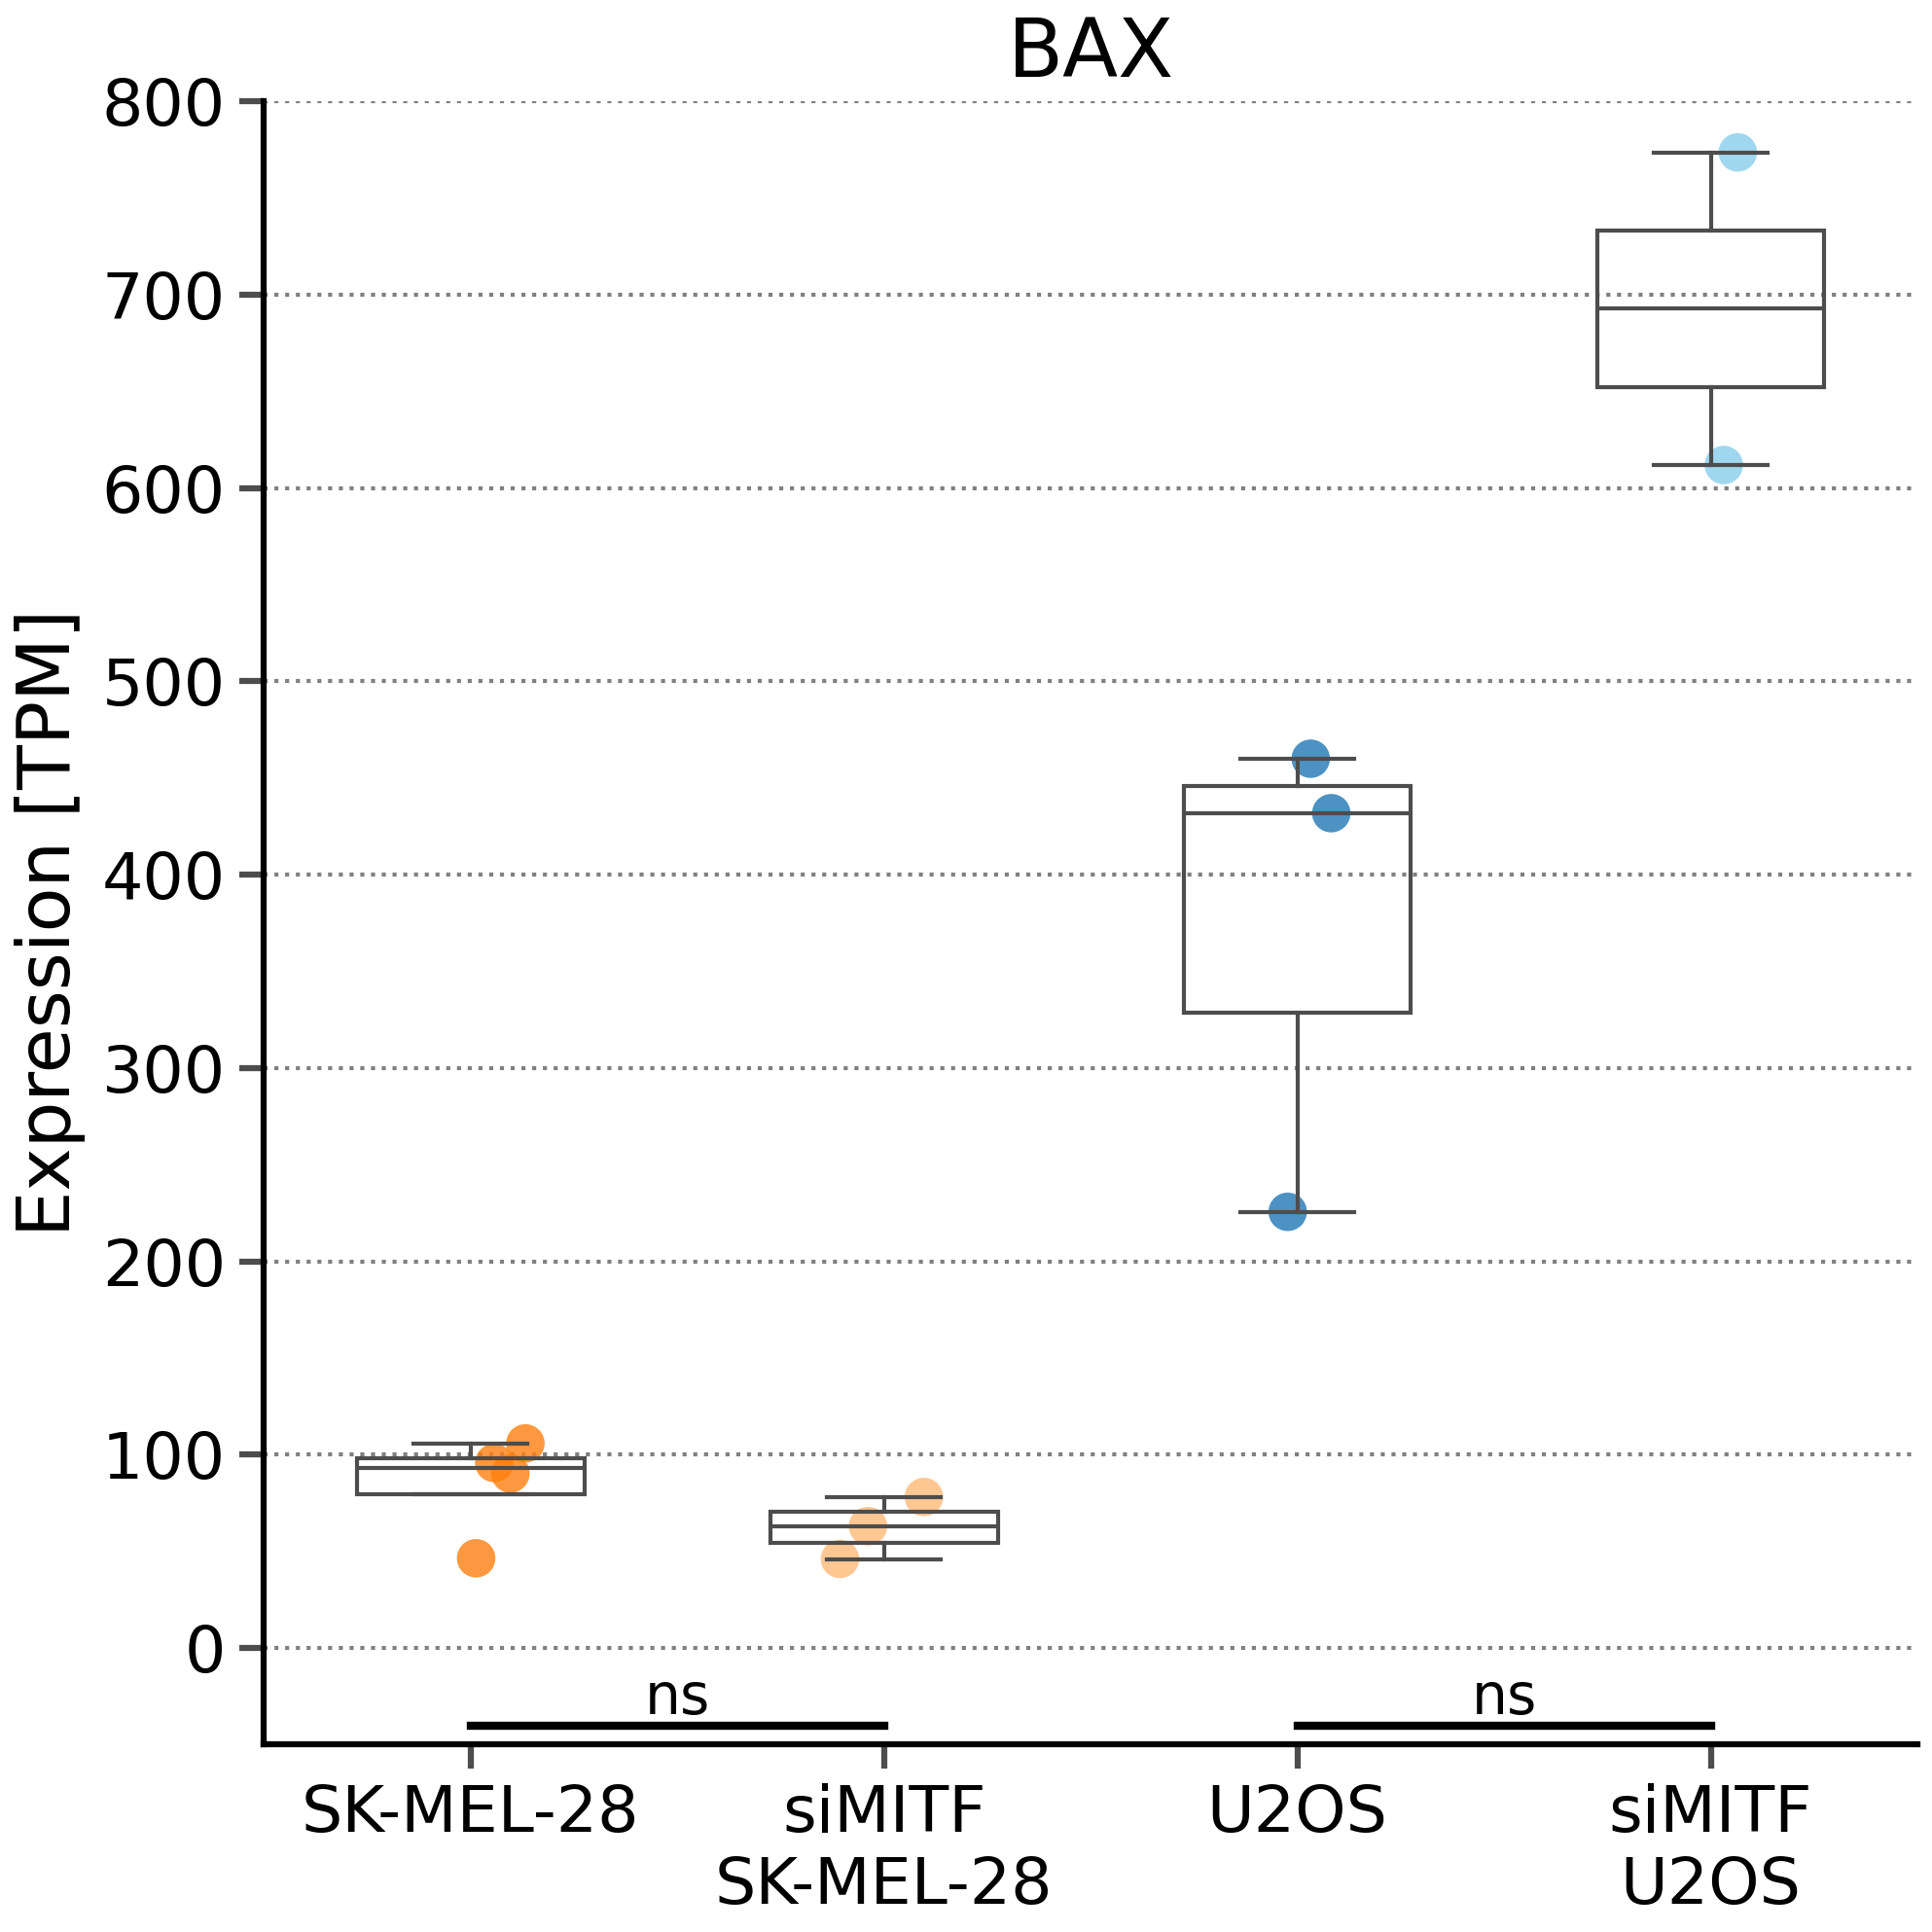

In [5]:
# deseq2 was using 1 and 3 for wt and 2 and 3 for si

bax = 'ENSG00000087088' 
p21 = 'ENSG00000124762'

s = expression.loc[bax, :]

is_skmel_ev   = s.index.str.contains(r"^SkMel28-MITFKO_ev_", regex=True)
is_skmel_mitf = s.index.str.contains(r"^SkMel28-MITFKO_mitf_x6_", regex=True)
is_u2_sc_ut   = s.index.str.contains(r"^U2-\d+_Sc_UT$", regex=True)
is_u2_simi_ut = s.index.str.contains(r"^U2-\d+_siMi_UT$", regex=True)

data = [
    s.loc[is_skmel_ev].to_numpy(),
    s.loc[is_skmel_mitf].to_numpy(),
    s.loc[is_u2_sc_ut].to_numpy(),
    s.loc[is_u2_simi_ut].to_numpy(),
]

# deseq2 was using 1 and 3 for wt and 2 and 3 for si
#data[-2] = numpy.delete(data[-2], 1) # 1 and 3 for wt
data[-1] = numpy.delete(data[-1], 0) # 2 and 3 for si

print(data)

labels = ["SK-MEL-28", "siMITF SK-MEL-28", "U2OS", "siMITF U2OS"]

tableau_colors = [
    "tab:orange",   # SK-MEL-28
    "#ffbb78",    # siMITF SK-MEL-28
    "tab:blue",     # U2OS
    "skyblue",      # siMITF U2OS
]



# statistics
t_skmel = scipy.stats.ttest_ind(data[0], data[1], equal_var=False)
t_u2os  = scipy.stats.ttest_ind(data[2], data[3], equal_var=False)

print()
print("SK-MEL-28 vs siMITF SK-MEL-28:", t_skmel.pvalue)
print("U2OS vs siMITF U2OS:",         t_u2os.pvalue)
print(scipy.stats.permutation_test((data[2], data[3]), statistic=lambda x, y: x.mean() - y.mean(), 
                             n_resamples=10_000, alternative="two-sided").pvalue)
print('log2fc', numpy.log2(numpy.median(data[3])/numpy.median(data[2])))
print('hedges', hedges_g(data[3], data[2]))




# Boxplot
fig, ax = matplotlib.pyplot.subplots()

ax.boxplot(
    data,
    widths=0.55,
    medianprops=dict(color="0.3", zorder=4),
    boxprops=dict(facecolor="none", edgecolor="0.3", zorder=3),
    whiskerprops=dict(color="0.3", zorder=3),
    capprops=dict(color="0.3", zorder=3),
)

for i, (values, color) in enumerate(zip(data, tableau_colors), start=1):
    x_jitter = numpy.random.normal(i, 0.06, size=len(values))
    ax.scatter(
        x_jitter,
        values,
        s=90,
        alpha=0.8,
        color=color,
        edgecolor="none",
        zorder=2
    )

ax.set_xticks(range(1, 5))
ax.set_xticklabels(["SK-MEL-28", "siMITF\nSK-MEL-28", "U2OS", "siMITF\nU2OS"])

ax.set_ylabel("Expression [TPM]")
ax.set_title("BAX")

ax.tick_params(axis="x", length=6, width=1.5, color="0.3")
ax.tick_params(axis="y", length=6, width=1.5, color="0.3")
ax.yaxis.grid(True, linestyle=":", linewidth=1, color="0.5", zorder=0)

ax.set_ylim(-50, 800)

# define ns bars
def add_ns(ax, x1, x2, y, h=0.02, text="ns"):
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=2, c="k")
    ax.text((x1+x2)/2, y+h, text, ha="center", va="bottom", fontsize=14)
add_ns(ax, 1, 2, y=-40)
add_ns(ax, 3, 4, y=-40)

matplotlib.pyplot.tight_layout()

matplotlib.rcParams["svg.fonttype"] = "none"
matplotlib.rcParams["pdf.fonttype"] = 42

matplotlib.pyplot.savefig("BAX_boxplot.svg", format="svg")

[array([1.67231615, 2.30434461, 2.07117847, 1.9947718 ]), array([4.78765544, 5.57033325, 5.47025318]), array([259.75526892, 209.06784689, 284.68161192]), array([550.93396963, 610.07902158])]

SK-MEL-28 vs siMITF SK-MEL-28: 0.0011022350796234931
U2OS vs siMITF U2OS: 0.010408226693102506
2.032975133889985 5.4702531802146


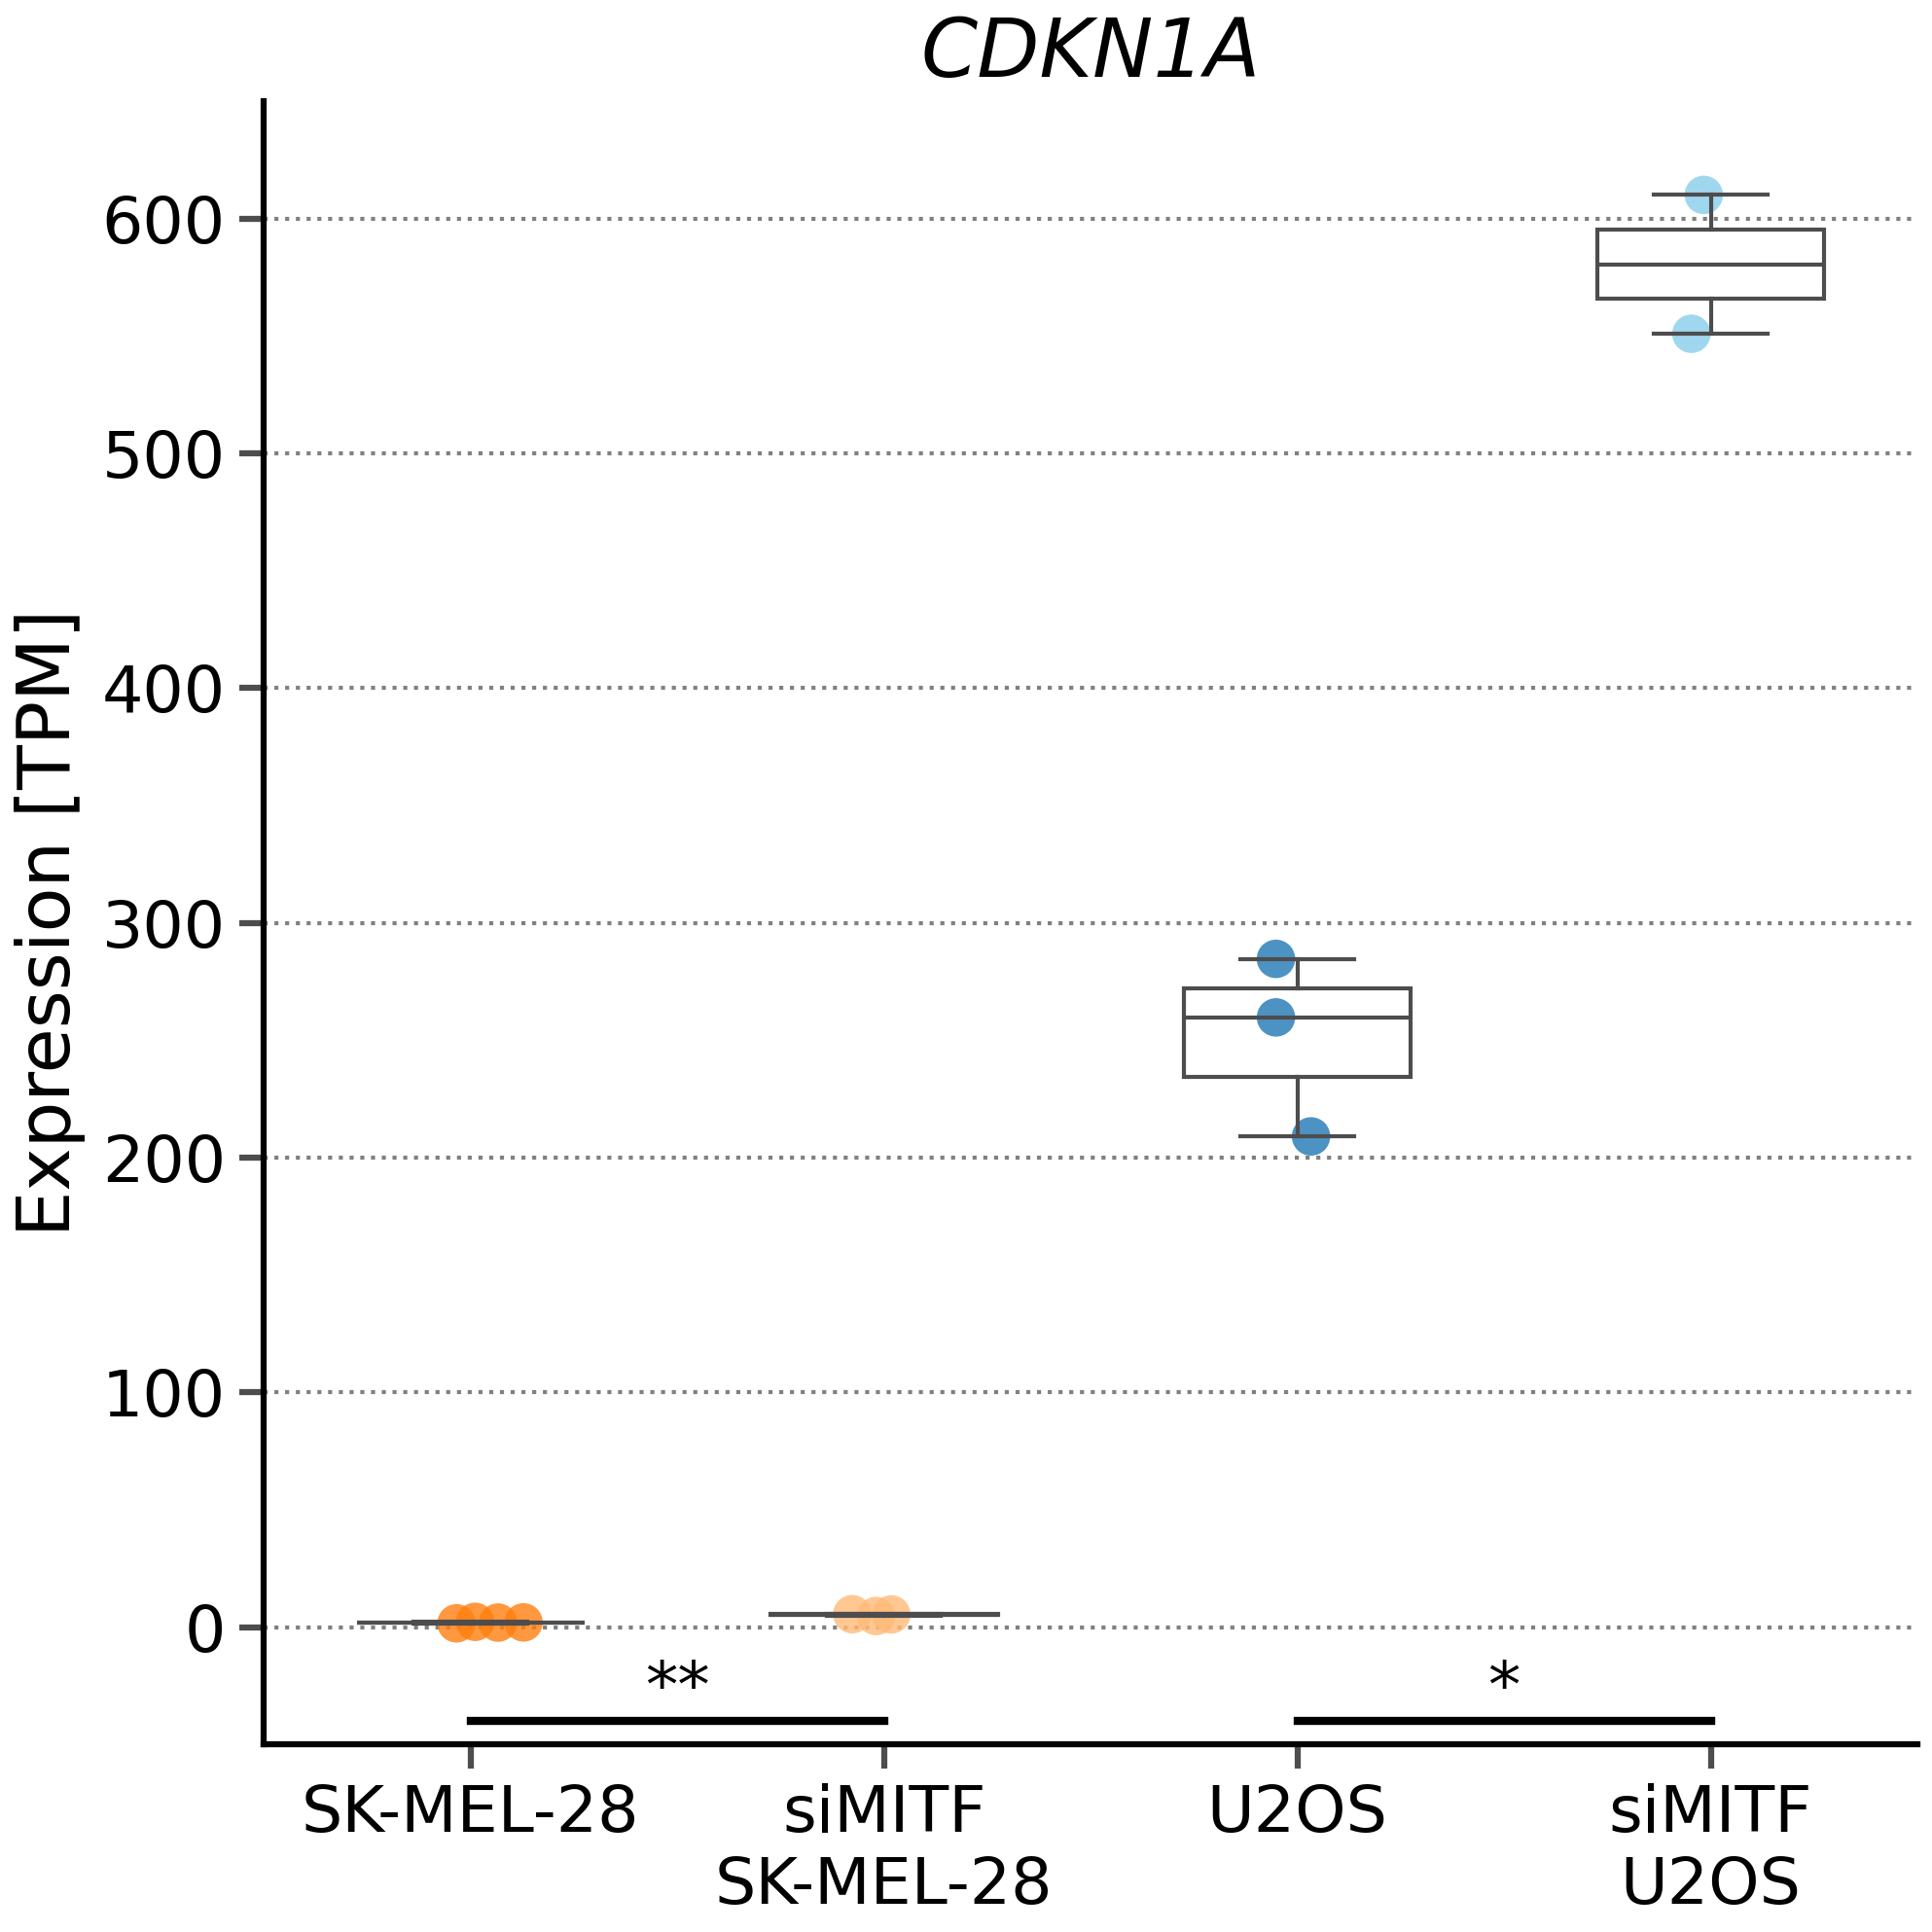

In [6]:
p21 = 'ENSG00000124762'

s = expression.loc[p21, :]

is_skmel_ev   = s.index.str.contains(r"^SkMel28-MITFKO_ev_", regex=True)
is_skmel_mitf = s.index.str.contains(r"^SkMel28-MITFKO_mitf_x6_", regex=True)
is_u2_sc_ut   = s.index.str.contains(r"^U2-\d+_Sc_UT$", regex=True)
is_u2_simi_ut = s.index.str.contains(r"^U2-\d+_siMi_UT$", regex=True)

data = [
    s.loc[is_skmel_ev].to_numpy(),
    s.loc[is_skmel_mitf].to_numpy(),
    s.loc[is_u2_sc_ut].to_numpy(),
    s.loc[is_u2_simi_ut].to_numpy(),
]

# deseq2 was using 1 and 3 for wt and 2 and 3 for si
#data[-2] = numpy.delete(data[-2], 1) # 1 and 3 for wt
data[-1] = numpy.delete(data[-1], 0) # 2 and 3 for si

print(data)

# statistics
t_skmel = scipy.stats.ttest_ind(data[0], data[1], equal_var=False)
t_u2os  = scipy.stats.ttest_ind(data[2], data[3], equal_var=False)
print()
print("SK-MEL-28 vs siMITF SK-MEL-28:", t_skmel.pvalue)
print("U2OS vs siMITF U2OS:",         t_u2os.pvalue)
print(numpy.median(data[0]), numpy.median(data[1]))

# Boxplot
fig, ax = matplotlib.pyplot.subplots()

ax.boxplot(
    data,
    widths=0.55,
    medianprops=dict(color="0.3", zorder=4),
    boxprops=dict(facecolor="none", edgecolor="0.3", zorder=3),
    whiskerprops=dict(color="0.3", zorder=3),
    capprops=dict(color="0.3", zorder=3),
)

for i, (values, color) in enumerate(zip(data, tableau_colors), start=1):
    x_jitter = numpy.random.normal(i, 0.06, size=len(values))
    ax.scatter(
        x_jitter,
        values,
        s=90,
        alpha=0.8,
        color=color,
        edgecolor="none",
        zorder=2
    )

ax.set_xticks(range(1, 5))
ax.set_xticklabels(["SK-MEL-28", "siMITF\nSK-MEL-28", "U2OS", "siMITF\nU2OS"])

ax.set_ylabel("Expression [TPM]")
ax.set_title("CDKN1A", fontstyle="italic")

ax.tick_params(axis="x", length=6, width=1.5, color="0.3")
ax.tick_params(axis="y", length=6, width=1.5, color="0.3")
ax.yaxis.grid(True, linestyle=":", linewidth=1, color="0.5", zorder=0)

#ax.set_ylim(-25, 800)

# define ns bars
def add_ns(ax, x1, x2, y, h=0.02, text="ns"):
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=2, c="k")
    ax.text((x1+x2)/2, y+h, text, ha="center", va="bottom", fontsize=16)
add_ns(ax, 1, 2, y=-40, text='**')
add_ns(ax, 3, 4, y=-40, text='*')

ax.set_ylim(-50, 650)


matplotlib.pyplot.tight_layout()


In [7]:
# 2. the genes for the cell cycle and apoptosis categories
# the file was retrieved from enrichr as reactome pathways 2024

rows = []
with open('Reactome_Pathways_2024.txt', newline='') as f:
    reader = csv.reader(f, delimiter='\t')   # adjust delimiter
    for row in reader:
        rows.append(row)

df = pandas.DataFrame(rows)
mask = df[0].str.contains('TP53 Regulates', case=False, na=False)
new = df[mask]
new = new.set_index(0)
new

values = new.loc['TP53 Regulates Transcription of Cell Cycle Genes', :].dropna().to_list()
genes_cycle = [value for value in values if value != '']
print(len(genes_cycle), genes_cycle[:5])

values = new.loc['TP53 Regulates Transcription of Cell Death Genes', :].dropna().to_list()
genes_death = [value for value in values if value != '']
print(len(genes_death), genes_death[:5])

values = new.loc['TP53 Regulates Transcription of DNA Repair Genes', :].dropna().to_list()
genes_repair = [value for value in values if value != '']
print(len(genes_repair), genes_repair[:5])

49 ['ARID3A', 'CNOT11', 'CNOT10', 'CDC25C', 'CNOT6']
44 ['ZNF420', 'CREBBP', 'PRELID1', 'APAF1', 'BNIP3L']
62 ['JUN', 'SUPT16H', 'GTF2F1', 'MSH2', 'GTF2F2']


In [8]:
# 3. convert gene symbols into ensembls

mg = mygene.MyGeneInfo()

mg = mygene.MyGeneInfo()
out = mg.querymany(genes_cycle,
                   scopes='symbol',
                   fields='ensembl.gene',
                   species='human',
                   as_dataframe=True, return_all=True)

print(out['ensembl.gene'].to_list()[:50])
print(out['ensembl'].to_list()[:50])

missing = []
nan_rows = out[pandas.isna(out['ensembl.gene'])]
for idx, row in nan_rows.iterrows():
    if isinstance(row['ensembl'], float) == False:
        for element in row['ensembl']:
            print(element)
        missing.append(element['gene'])
    print()
print(len(missing))
all_ids = out['ensembl.gene'].to_list() + missing
print(len(all_ids), all_ids[:50])
unique = list(set(all_ids))
ensembl_repair = list(filter(pandas.notna, unique))
print(len(ensembl_repair), ensembl_repair[:50])

out





Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
2 input query terms found no hit:	['CENPJ', 'RQCD1']


['ENSG00000116017', 'ENSG00000158435', nan, 'ENSG00000158402', 'ENSG00000113300', 'ENSG00000198791', 'ENSG00000080839', 'ENSG00000155508', 'ENSG00000103479', 'ENSG00000125107', nan, 'ENSG00000111596', nan, 'ENSG00000080802', 'ENSG00000123374', 'ENSG00000087088', 'ENSG00000142453', 'ENSG00000170312', 'ENSG00000141510', 'ENSG00000132646', 'ENSG00000159388', 'ENSG00000087586', 'ENSG00000101412', 'ENSG00000205250', 'ENSG00000165891', 'ENSG00000129173', 'ENSG00000138767', 'ENSG00000181163', 'ENSG00000116717', 'ENSG00000173846', 'ENSG00000145632', 'ENSG00000126457', 'ENSG00000145386', 'ENSG00000133101', 'ENSG00000102760', 'ENSG00000198176', 'ENSG00000114126', 'ENSG00000175305', 'ENSG00000105173', nan, 'ENSG00000111276', 'ENSG00000124762', 'ENSG00000134057', 'ENSG00000090097', 'ENSG00000100393', 'ENSG00000118495', 'ENSG00000175793', 'ENSG00000149115', 'ENSG00000161642']
[nan, nan, [{'gene': 'ENSG00000182973'}, {'gene': 'ENSG00000291502'}], nan, nan, nan, nan, nan, nan, nan, nan, nan, [{'gene'

,_id,_score,ensembl.gene,ensembl,notfound
query,,,,,
ARID3A,1820,17.690210,ENSG00000116017,NaN,NaN
CNOT11,55571,17.630966,ENSG00000158435,NaN,NaN
CNOT10,25904,17.612848,NaN,"[{'gene': 'ENSG00000182973'}, {'gene': 'ENSG00...",NaN
CDC25C,995,18.805180,ENSG00000158402,NaN,NaN
CNOT6,57472,18.287443,ENSG00000113300,NaN,NaN
CNOT7,29883,17.609568,ENSG00000198791,NaN,NaN
RBL1,5933,17.597040,ENSG00000080839,NaN,NaN
CNOT8,9337,17.623825,ENSG00000155508,NaN,NaN
RBL2,5934,17.582138,ENSG00000103479,NaN,NaN


In [9]:
# make a heatmap

In [10]:
mini = expression[expression.index.isin(ensembl_repair)]
print(mini.shape)

#mini = mini[mini.max(axis=1) > 2]
#print(mini.shape)

#mini = sub[(sub.max(axis=1) - sub.min(axis=1)) > 20]
#print(mini.shape)

df_z = mini.sub(mini.mean(axis=1), axis=0).div(mini.std(axis=1), axis=0)
print(df_z.shape)

(45, 13)
(45, 13)


In [11]:
mini

,SkMel28-MITFKO_ev_skmel28_rep1,SkMel28-MITFKO_ev_skmel28_rep2,SkMel28-MITFKO_ev_skmel28_rep3,SkMel28-MITFKO_ev_skmel28_rep4,SkMel28-MITFKO_mitf_x6_rep1,SkMel28-MITFKO_mitf_x6_rep3,SkMel28-MITFKO_mitf_x6_rep4,U2-1_Sc_UT,U2-2_Sc_UT,U2-3_Sc_UT,U2-1_siMi_UT,U2-2_siMi_UT,U2-3_siMi_UT
ENSG00000080802,13.697015,14.300937,18.406012,11.077693,17.093202,15.109866,10.813326,7.339774,13.172636,7.962264,14.314748,8.762182,9.640899
ENSG00000080839,17.529053,16.807061,31.966491,13.977537,31.139671,12.694784,9.145882,9.365403,13.539146,9.735707,11.516723,4.068796,4.403804
ENSG00000087088,105.815707,90.223086,46.404786,95.682582,46.024698,63.026497,78.082203,431.750944,225.573704,459.925695,409.950427,611.817959,773.511277
ENSG00000087586,163.178894,163.323040,250.293763,238.353745,129.398004,129.473048,77.092281,173.505657,88.034440,196.724675,61.930045,121.818025,106.823900
ENSG00000090097,112.255099,111.299889,79.167446,86.638737,103.940734,131.119493,124.102788,103.531697,22.366395,107.452168,41.644278,214.749720,207.218711
ENSG00000100393,26.993459,28.880876,54.160365,18.834281,30.141401,29.750546,15.097530,25.713580,27.810988,23.358654,26.304831,29.523895,28.028021
ENSG00000101412,42.343940,42.789396,34.701921,36.298282,41.479852,38.969269,32.590135,39.932566,25.467302,38.138657,28.880796,18.651495,23.160651
ENSG00000102760,0.939675,0.939287,0.000000,0.357466,0.000000,0.455789,0.249972,1.512260,13.282459,0.854097,4.373888,3.519160,2.441058
ENSG00000103479,13.884995,14.083600,14.853854,16.083266,26.926373,16.812937,18.495706,16.721567,22.246964,14.968513,26.348148,18.177864,17.203529
ENSG00000105173,14.618516,15.299193,17.710128,12.038848,19.573526,14.164165,11.134887,49.253553,29.344002,50.103244,19.156269,37.800935,44.606821


In [12]:
map_df = mg.querymany(df_z.index,
                   scopes='ensembl.gene',
                   fields='symbol',
                   species='human',
                   as_dataframe=True, return_all=True)

df_z = df_z.rename(index=map_df["symbol"])


Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed


In [13]:
df_z

,SkMel28-MITFKO_ev_skmel28_rep1,SkMel28-MITFKO_ev_skmel28_rep2,SkMel28-MITFKO_ev_skmel28_rep3,SkMel28-MITFKO_ev_skmel28_rep4,SkMel28-MITFKO_mitf_x6_rep1,SkMel28-MITFKO_mitf_x6_rep3,SkMel28-MITFKO_mitf_x6_rep4,U2-1_Sc_UT,U2-2_Sc_UT,U2-3_Sc_UT,U2-1_siMi_UT,U2-2_siMi_UT,U2-3_siMi_UT
CNOT4,0.361776,0.535275,1.714614,-0.390724,1.337460,0.767671,-0.466673,-1.464583,0.211128,-1.285749,0.539243,-1.055942,-0.803497
RBL1,0.373413,0.289940,2.042585,-0.037193,1.946993,-0.185497,-0.595801,-0.570421,-0.087877,-0.527608,-0.321698,-1.182784,-1.144052
BAX,-0.646146,-0.709660,-0.888145,-0.687421,-0.889693,-0.820439,-0.759113,0.681486,-0.158336,0.796250,0.592686,1.414953,2.073578
AURKA,0.290710,0.293171,1.777895,1.574061,-0.285982,-0.284701,-1.178921,0.467004,-0.992122,0.863388,-1.437764,-0.415384,-0.671357
PCBP4,0.019700,0.002011,-0.593045,-0.454685,-0.134272,0.369046,0.239105,-0.141847,-1.644934,-0.069245,-1.287930,1.917780,1.778315
EP300,-0.116697,0.092558,2.895251,-1.021291,0.232310,0.188976,-1.435578,-0.258595,-0.026059,-0.519682,-0.193044,0.163848,-0.001997
E2F1,1.049117,1.105861,0.075653,0.279002,0.939047,0.619241,-0.193353,0.741949,-1.100682,0.513435,-0.665860,-1.968901,-1.394510
RGCC,-0.357960,-0.358068,-0.619656,-0.520103,-0.619656,-0.492720,-0.550040,-0.198498,3.079455,-0.381793,0.598454,0.360416,0.060169
RBL2,-0.998437,-0.952652,-0.775081,-0.491658,2.008061,-0.323443,0.064494,-0.344508,0.929292,-0.748648,1.874759,-0.008779,-0.233398
CCNE1,-0.760264,-0.713792,-0.549190,-0.936386,-0.421970,-0.791284,-0.998102,1.604374,0.245089,1.662385,-0.450458,0.822469,1.287128


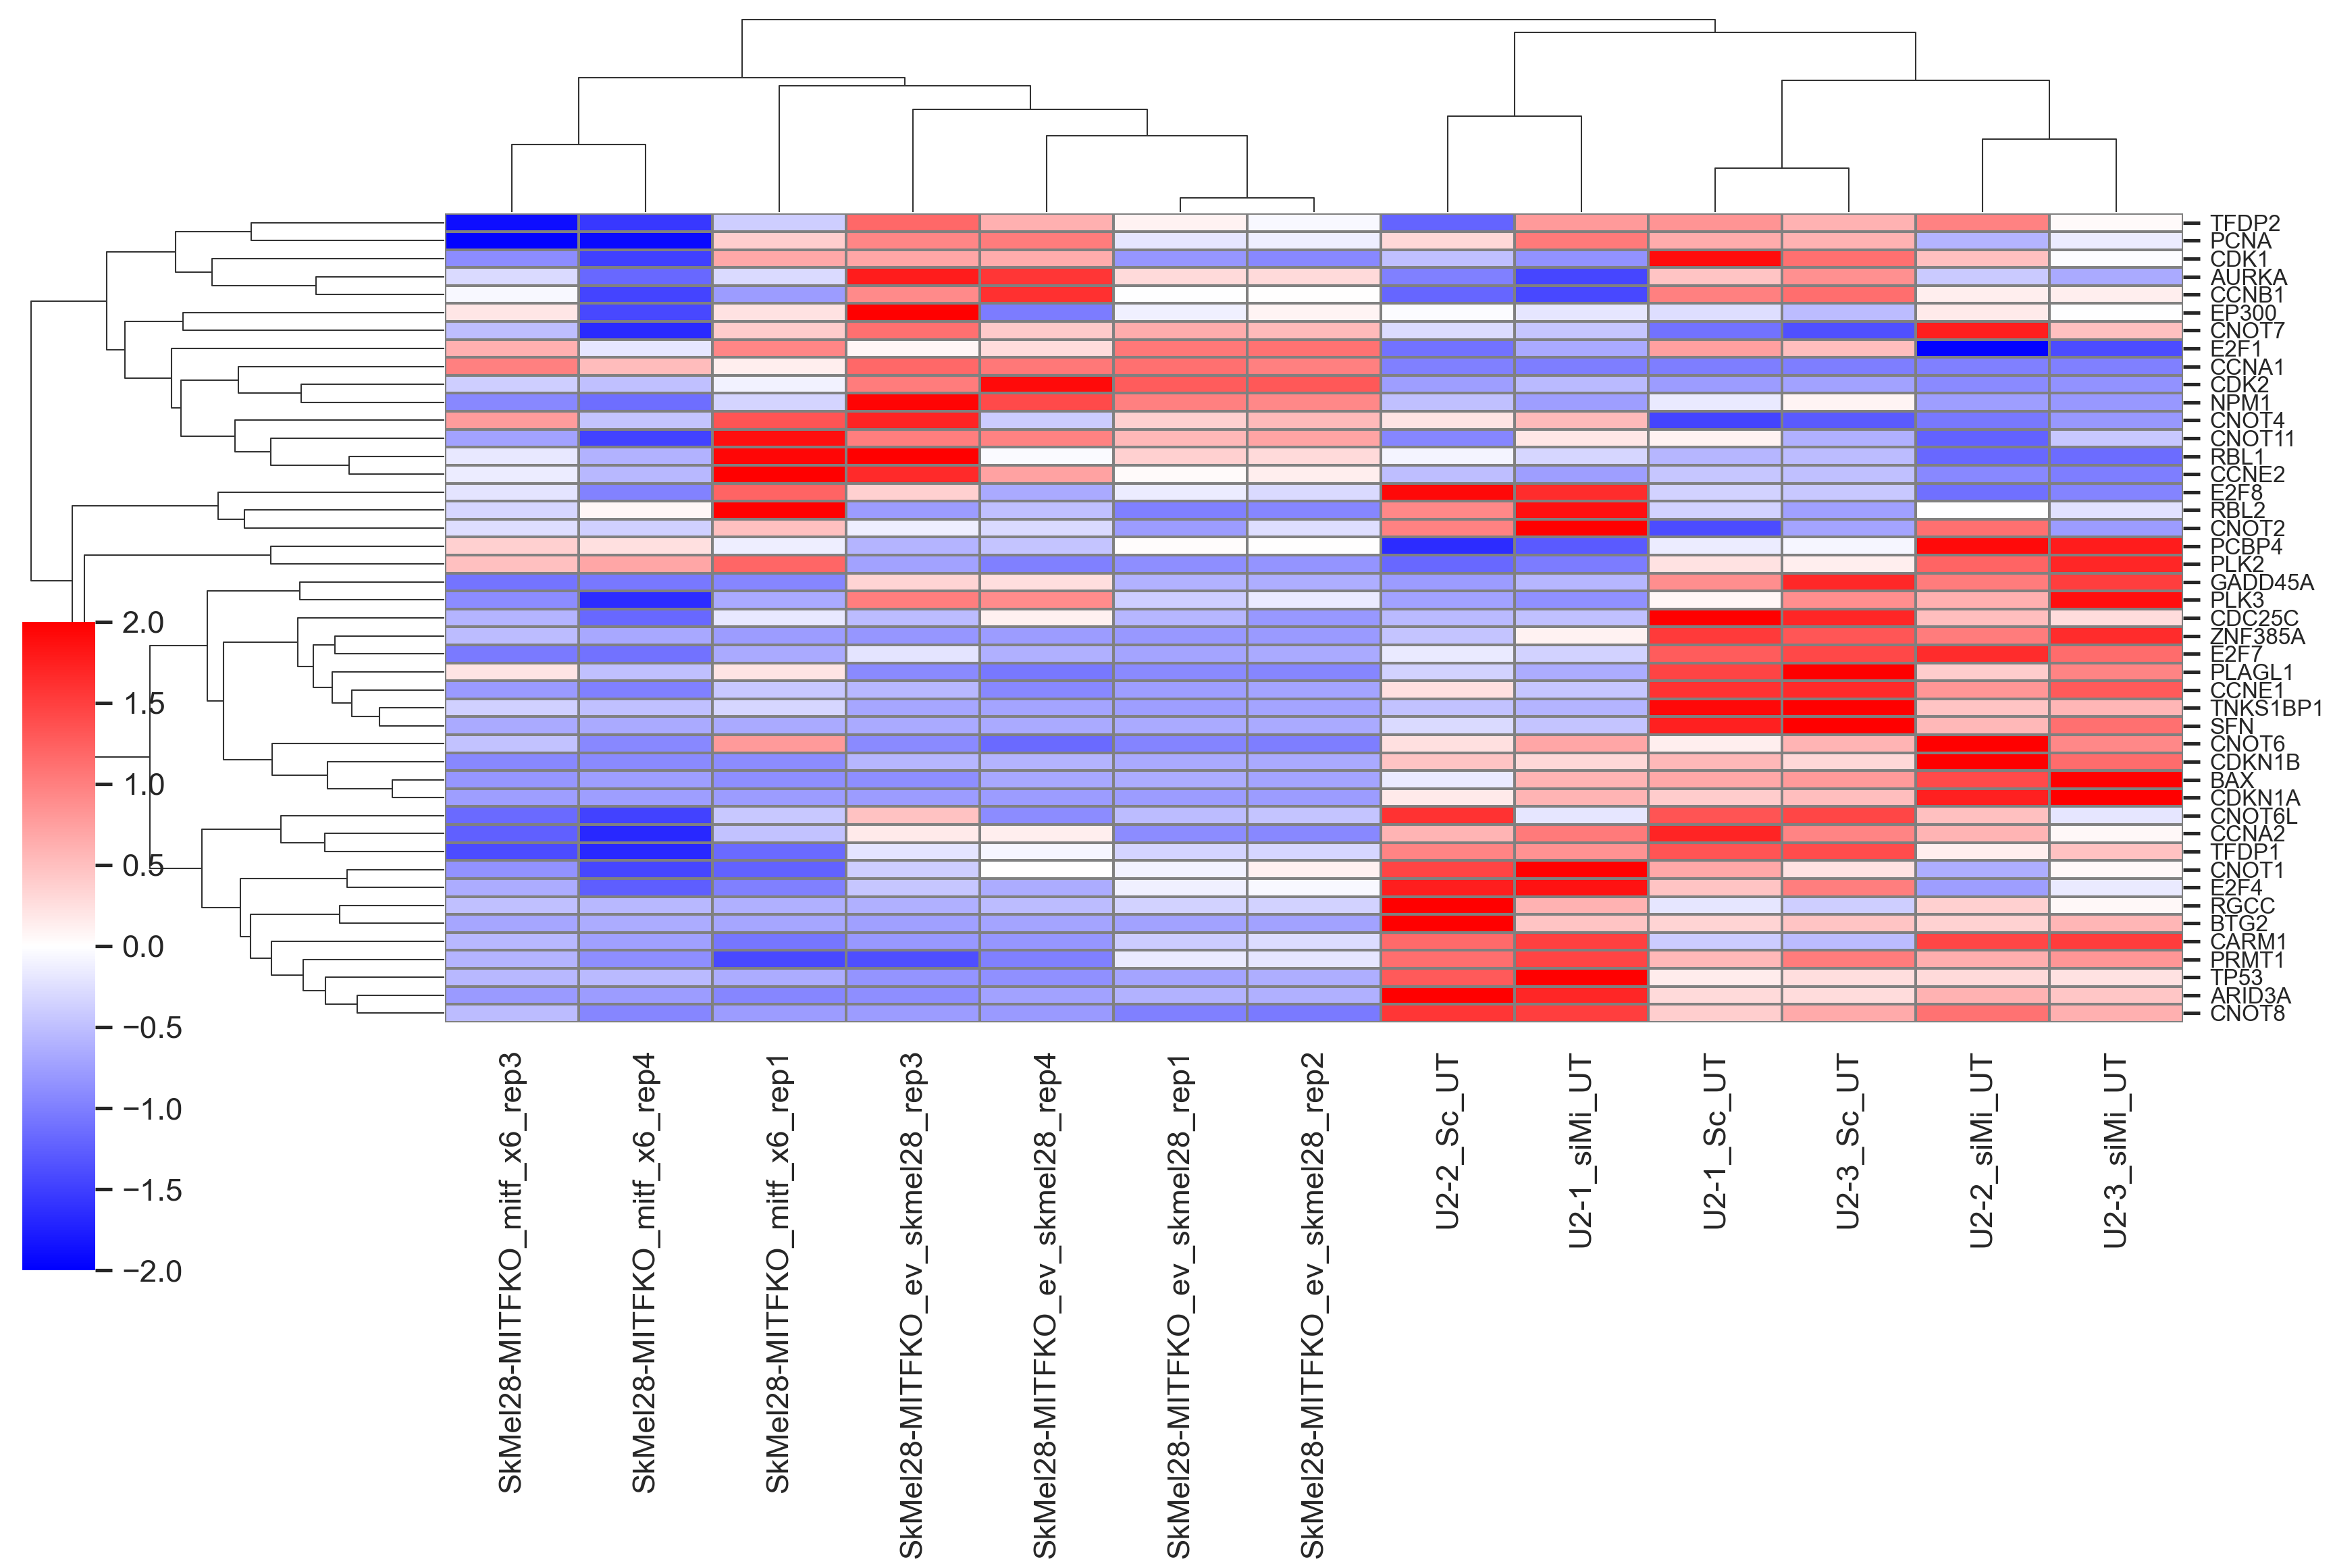

In [14]:
seaborn.set(style="white")          # aesthetic style (optional)

g = seaborn.clustermap(
    df_z,
    method='average',           # linkage method: 'single', 'complete', 'ward', …
    metric='euclidean',         # distance metric
    cmap='bwr',             # colour map for the heat‑map
    figsize=(12, 8),
    linewidths=.5,
    linecolor='gray',
    dendrogram_ratio=(.2, .2),  # proportion of figure devoted to dendrograms
    cbar_pos=(0.02, .2, .03, .4), # position of colour bar (optional)
    vmin=-2,
    yticklabels=True,
    vmax= 2
)
g.ax_heatmap.tick_params(axis="y", labelsize=8)
